# Sentiment Analysis using ML models

Step1: Import Libraries

In [14]:
#Data handling
import pandas as pd
import numpy as np

#Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

#Text processing
import re
import string
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

#Models 
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

#Evaluation
from sklearn.metrics import accuracy_score,confusion_matrix, classification_report
import joblib

#Ignore warnings
import warnings
warnings.filterwarnings("ignore")

#Plot settings
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

## Step 2:Load Dataset

In [15]:
#Load the csv file
df = pd.read_csv("sentimentdataset.csv")

#Display first few rows
df.head()


,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


In [16]:
#Dataset info
print("\n Dataset Information:")
df.info()

#Check missing value
print("\n Dataset Information:")
print(df.isnull().sum())

#Quick Statistical summary
print("\n Numerical Summary:")
print(df.describe())

#Check unique sentiment labels
print("\n Sentiment Classification:")
print(df['Sentiment'].value_counts())


 Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0.1  732 non-null    int64  
 1   Unnamed: 0    732 non-null    int64  
 2   Text          732 non-null    str    
 3   Sentiment     732 non-null    str    
 4   Timestamp     732 non-null    str    
 5   User          732 non-null    str    
 6   Platform      732 non-null    str    
 7   Hashtags      732 non-null    str    
 8   Retweets      732 non-null    float64
 9   Likes         732 non-null    float64
 10  Country       732 non-null    str    
 11  Year          732 non-null    int64  
 12  Month         732 non-null    int64  
 13  Day           732 non-null    int64  
 14  Hour          732 non-null    int64  
dtypes: float64(2), int64(6), str(7)
memory usage: 85.9 KB

 Dataset Information:
Unnamed: 0.1    0
Unnamed: 0      0
Text            0
Sentiment       

## Step4: Exploratory Data Analysis(EDA)

<class 'pandas.DataFrame'>
Index: 332 entries, 0 to 731
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0.1  332 non-null    int64  
 1   Unnamed: 0    332 non-null    int64  
 2   Text          332 non-null    str    
 3   Sentiment     332 non-null    str    
 4   Timestamp     332 non-null    str    
 5   User          332 non-null    str    
 6   Platform      332 non-null    str    
 7   Hashtags      332 non-null    str    
 8   Retweets      332 non-null    float64
 9   Likes         332 non-null    float64
 10  Country       332 non-null    str    
 11  Year          332 non-null    int64  
 12  Month         332 non-null    int64  
 13  Day           332 non-null    int64  
 14  Hour          332 non-null    int64  
 15  Clean_Text    332 non-null    str    
dtypes: float64(2), int64(6), str(8)
memory usage: 44.1 KB


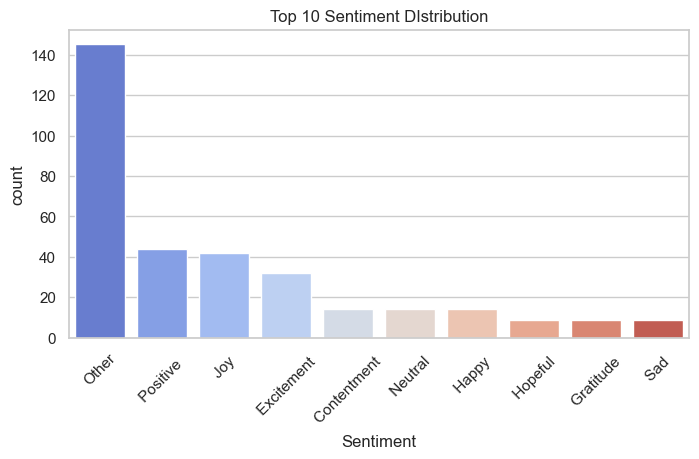

In [29]:
#Get top 10 sentiments by count
top_sentiments =df['Sentiment'].value_counts().nlargest(10).index
df_top = df[df['Sentiment'].isin(top_sentiments)]
df_top.info()

#4.1 Sentiment Distribution 
plt.figure(figsize=(8,4))
sns.countplot(data= df_top, x='Sentiment',palette='coolwarm', order=top_sentiments)
plt.title('Top 10 Sentiment DIstribution')
plt.xticks(rotation=45)
plt.show()

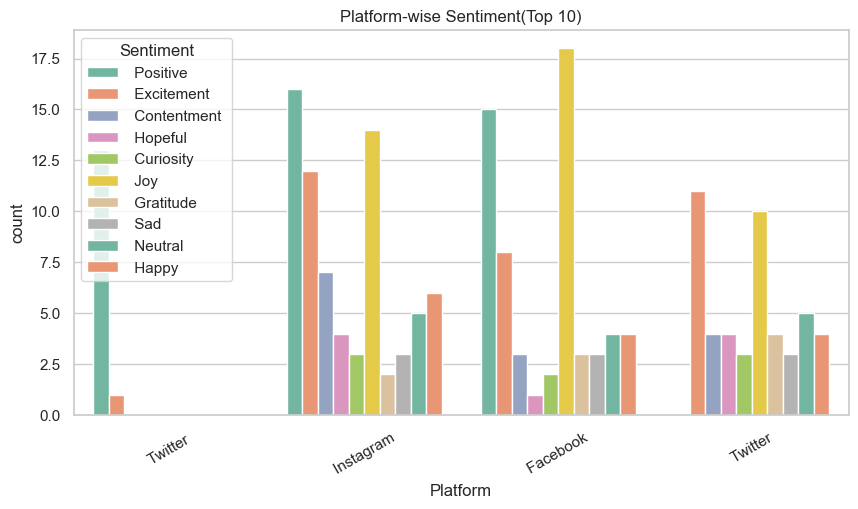

In [18]:
#4.2 Platform-wise Sentiment Distribution
plt.figure(figsize=(10,5))
sns.countplot(data=df_top, x='Platform' , hue='Sentiment' , palette='Set2')
plt.title('Platform-wise Sentiment(Top 10)')
plt.xticks(rotation=30)
plt.show()

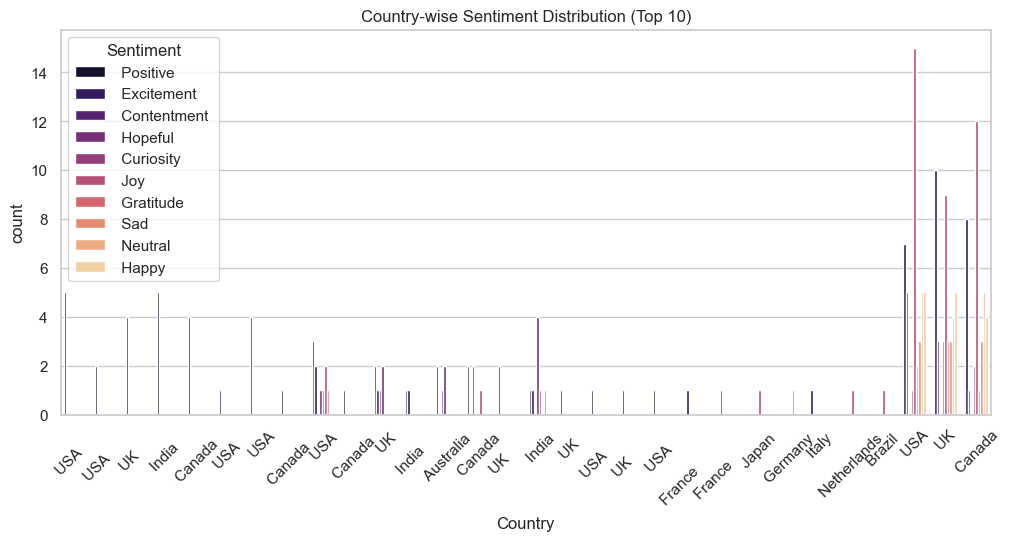

In [19]:
#4.3 Country-wise Sentiment
plt.figure(figsize=(12,5))
sns.countplot(data=df_top, x='Country',hue='Sentiment',palette='magma')
plt.title('Country-wise Sentiment Distribution (Top 10)')
plt.xticks(rotation=45)
plt.show()

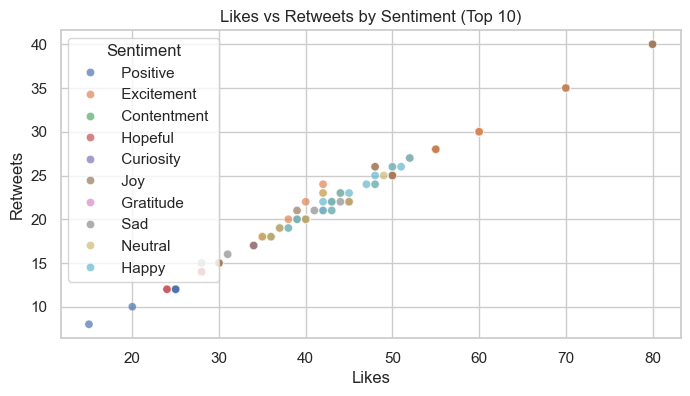

In [20]:
#4.4 likes vs Retweets
plt.figure(figsize=(8,4))
sns.scatterplot(data = df_top, x='Likes',y='Retweets',hue='Sentiment',alpha=0.7)
plt.title('Likes vs Retweets by Sentiment (Top 10)')
plt.show()

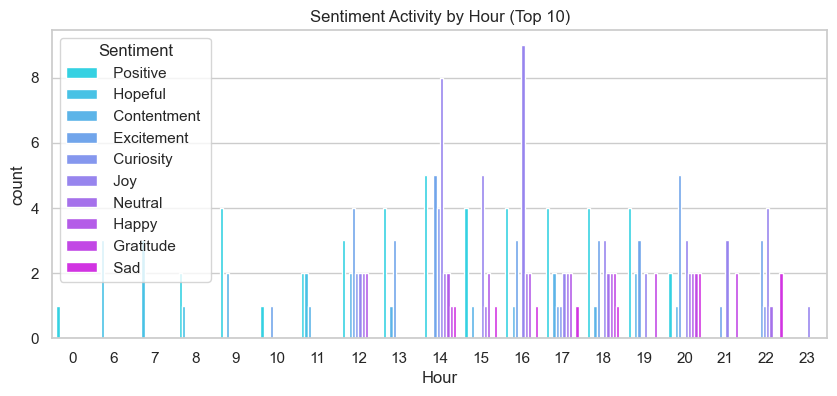

In [21]:
## Sentiment Trend Over Hours
plt.figure(figsize=(10,4))
sns.countplot(data=df_top, x='Hour', hue='Sentiment', palette='cool')
plt.title('Sentiment Activity by Hour (Top 10)')
plt.show()

## Step 5: Text Cleaning & Preprocessing

In [22]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+","",text) #remove URLs
    text = re.sub(r"@\w+","", text)  #remove mentions
    text = re.sub(r"#\w+","", text)  #remove hashtags
    text = re.sub(r"[^a-z\s]","", text)  #keep only letters
    text = " ".join([word for word in text.split() if word not in stop_words])
    return text.strip()


df['Clean_Text'] = df['Text'].apply(clean_text)
df[['Text', 'Clean_Text']].head(10)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Arzoo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,Text,Clean_Text
0,Enjoying a beautiful day at the park! ...,enjoying beautiful day park
1,Traffic was terrible this morning. ...,traffic terrible morning
2,Just finished an amazing workout! 💪 ...,finished amazing workout
3,Excited about the upcoming weekend getaway! ...,excited upcoming weekend getaway
4,Trying out a new recipe for dinner tonight. ...,trying new recipe dinner tonight
5,Feeling grateful for the little things in lif...,feeling grateful little things life
6,Rainy days call for cozy blankets and hot coc...,rainy days call cozy blankets hot cocoa
7,The new movie release is a must-watch! ...,new movie release mustwatch
8,Political discussions heating up on the timel...,political discussions heating timeline
9,Missing summer vibes and beach days. ...,missing summer vibes beach days


# Step 6: Text Analysis

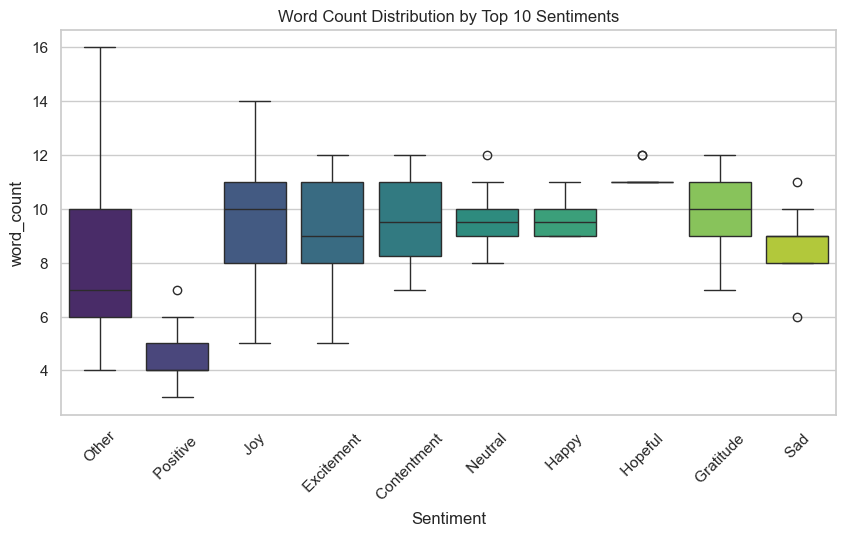


Top words for Other:


,Word,Frequency
0,night,9
1,symphony,8
2,ancient,6
3,like,6
4,joy,6



Top words for  Positive  :


,Word,Frequency
0,new,10
1,day,4
2,weekend,4
3,feeling,4
4,enjoying,3



Top words for  Joy :


...

,Word,Frequency
0,hopeful,8
1,optimism,6
2,brighter,5
3,tomorrow,5
4,towards,4



Top words for  Gratitude :


,Word,Frequency
0,gratitude,3
1,story,3
2,writing,3
3,every,3
4,thankfulness,2



Top words for  Sad :


,Word,Frequency
0,feeling,5
1,challenges,2
2,sometimes,2
3,unexpected,2
4,missing,2


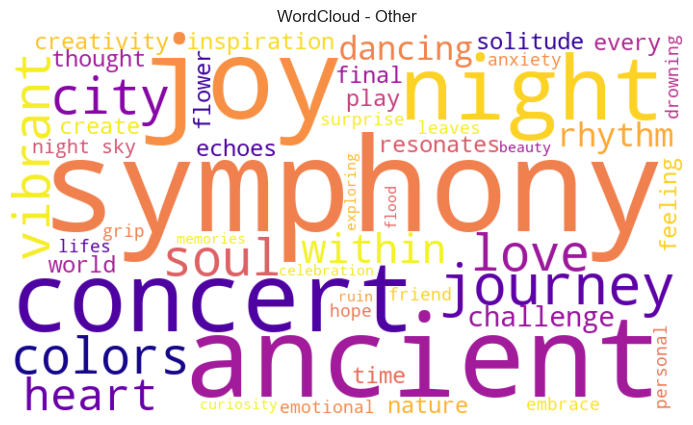

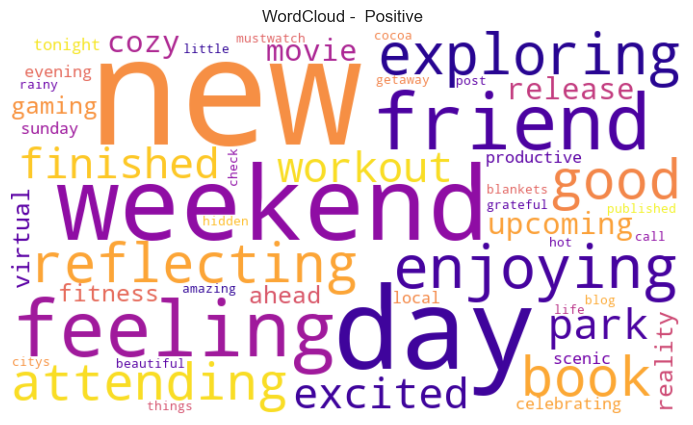

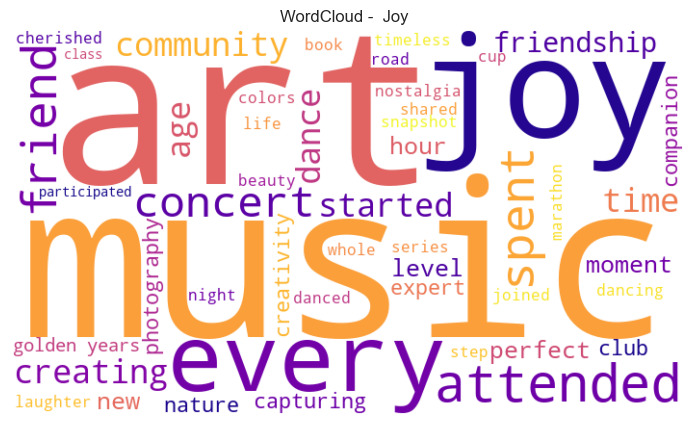

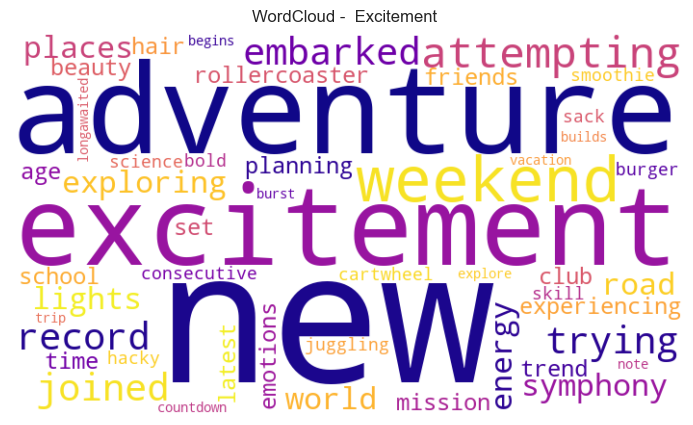

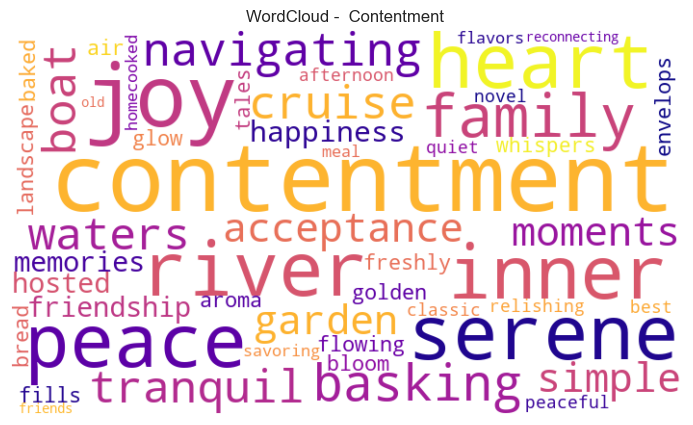

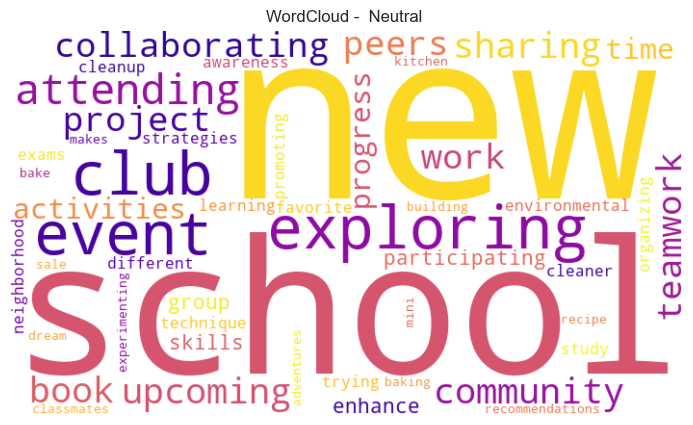

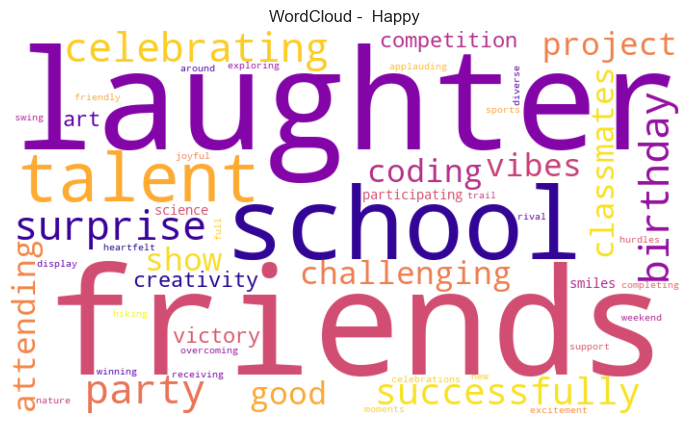

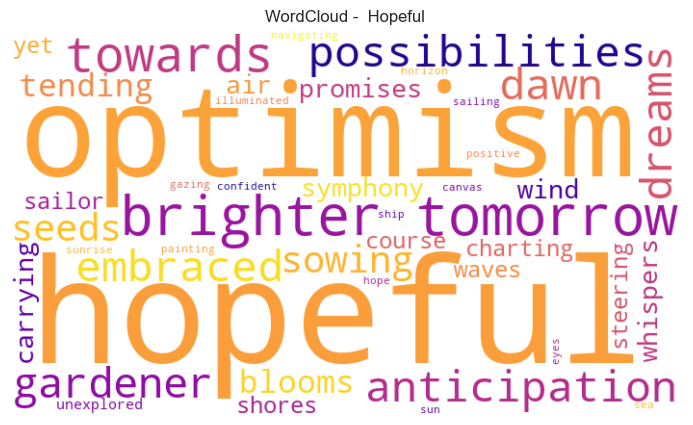

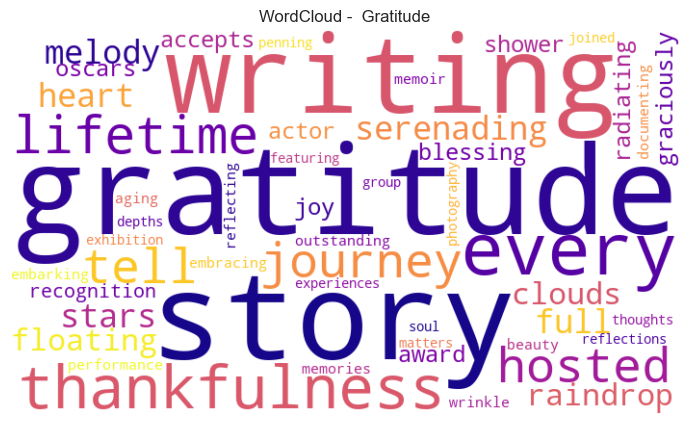

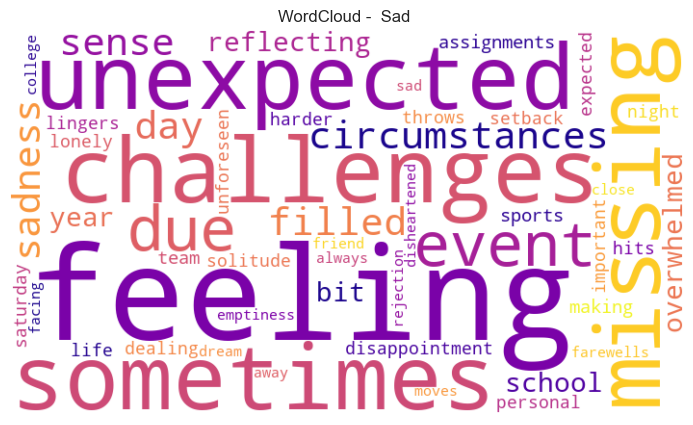

In [30]:
# Select top 10 most frequent sentiments
top_sentiments = df["Sentiment"].value_counts().nlargest(10).index
df_top = df[df['Sentiment'].isin(top_sentiments)]

# 6.1 Average Word Count per Sentiment (Top 10)
df_top['word_count'] = df_top['Clean_Text'].apply(lambda x: len(x.split()))
plt.figure(figsize=(10,5))
sns.boxplot(data=df_top, x='Sentiment', y='word_count', palette='viridis',order=top_sentiments)
plt.title('Word Count Distribution by Top 10 Sentiments')
plt.xticks(rotation=45)
plt.show()

# 6.2 Most Common Words per Sentiment (Top 10 sentiments,top 5 words each)
def most_common_words(sentiment, n=5):
    words = " ".join(df_top[df_top['Sentiment']==sentiment]['Clean_Text']).split()
    common = Counter(words).most_common(n)
    return pd.DataFrame(common,columns =['Word','Frequency'])

for s in  top_sentiments:
    print(f"\nTop words for {s}:")
    display(most_common_words(s, n=5)) # only top 5 words

# 6.2 Most Common Words per Sentiment (Top 10 sentiments, top 5 words each)
# def most_common_words(sentiment, n=5):
#     words = " ".join(df_top[df_top['Sentiment']==sentiment]['Clean_Text'])
#     common = Counter(words).most_common(n)
#     return pd.DataFrame(common, columns=['Word','Frequency'])

# for s in top_sentiments:
#     print(f"\nTop words for {s}:")
#     display(most_common_words(s, n=5))  # only top 5 words

#6.3 WordCLouds for top 10 Sentiments:
for sentiment in top_sentiments:
    text = " ".join(df_top[df_top['Sentiment']==sentiment]['Clean_Text'])
    wc = WordCloud(width=700, height=400, background_color='white',colormap='plasma' ,max_words=50).generate(text)
    plt.figure(figsize=(10,5))
    plt.imshow(wc,interpolation='bilinear')
    plt.axis('off')
    plt.title(f"WordCloud - {sentiment}")
    plt.show()

#This entire block is EDA (Exploratory Data Analysis). You're answering questions like:

# Which sentiments appear most often?
# How long are the texts for each sentiment?
# Which words are most common within each sentiment?
# What do those words look like visually in a word cloud?

### 

### Step 7: Feature Extraction

In [25]:
#combine rare classes with<2 samples into 'Other'
counts = df['Sentiment'].value_counts()
rare_classes = counts[counts <2].index
df['Sentiment'] = df['Sentiment'].replace(rare_classes,'Other')

#TF-IDF
tfidf =TfidfVectorizer(
    max_features=15000,
    ngram_range=(1,3),
    min_df=2,
    max_df=0.95
)
X=tfidf.fit_transform(df['Clean_Text'])
y= df['Sentiment']

#Train/Test Split with stratify
X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state = 42 ,stratify = y
)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (585, 1758) Test shape: (147, 1758)


### Step 8:Model Training

In [32]:
models={
    "Logistic Regression": LogisticRegression(max_iter=200),
    "Naive Bayes": MultinomialNB(),
    "Linear SVM" : LinearSVC(),
    "Random Forest" : RandomForestClassifier(n_estimators=200,random_state=42)
}

results={}

for name, model in models.items():
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test,y_pred)
    results[name] = acc
    print(f"{name} Accuracy: {acc:4f}")

Logistic Regression Accuracy: 0.217687
Naive Bayes Accuracy: 0.197279
Linear SVM Accuracy: 0.462585
Random Forest Accuracy: 0.435374


### Step 9: Visual Comparision of Model Accuracies

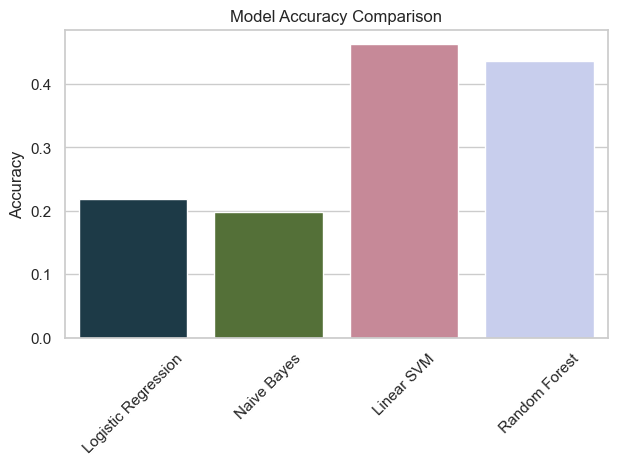


 ✅ Best Performing Model:Linear SVM ( 46.26% accuracy)


In [35]:
# plt.figure(figsize=(7,4))
# sns.barplot(x=list(results.keys()),y=list(results.values()), palette='cubehelix')
# plt.title('Model Accuracy Comparison')
# plt.ylable('Accuracy')
# plt.xticks(rotation=45)
# plt.show()


plt.figure(figsize=(7,4))
sns.barplot(x=list(results.keys()), y=list(results.values()), palette='cubehelix')
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.show()

best_model_name = max(results,key=results.get)
print(f"\n ✅ Best Performing Model:{best_model_name} ({results[best_model_name]: .2%} accuracy)")

### Step 10: Detailed Evaluation of Best Model

In [36]:
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test)

print("\nClassification Report:")
print(classification_report(y_test,y_pred_best))


Classification Report:
                   precision    recall  f1-score   support

    Acceptance          0.00      0.00      0.00         1
 Acceptance             0.50      1.00      0.67         1
  Accomplishment        0.00      0.00      0.00         1
    Adoration           1.00      1.00      1.00         1
       Adventure        0.00      0.00      0.00         1
 Ambivalence            1.00      1.00      1.00         1
    Anticipation        0.00      0.00      0.00         0
   Arousal              1.00      1.00      1.00         1
             Awe        0.00      0.00      0.00         1
             Bad        1.00      1.00      1.00         1
        Betrayal        0.50      1.00      0.67         1
    Bitter              0.50      1.00      0.67         1
      Bitterness        1.00      1.00      1.00         1
 Boredom                1.00      1.00      1.00         1
    Calmness            0.00      0.00      0.00         1
     Captivation        0.00   

### Step 11: Save the Best Model and Vectorizer

In [37]:
joblib.dump(best_model,"best_sentiment_model.pk1")
joblib.dump(tfidf,"tfidf_vectorizer.pk1")
print("\n Model and TF-IDF Vectorizer saved successfully!")



 Model and TF-IDF Vectorizer saved successfully!


### Step 12: Predict Sentiment on New Text

In [40]:
def predict_sentiment(text):
    clean = clean_text(text)
    vec = tfidf.transform([clean])
    pred = best_model.predict(vec)[0]
    return pred 

samples=[
    "I hate this movie!",
    "I love the experience so much",
    "I am so glad i came today",
    "It made me so bad to leave today, that i cried",
    "The service was awful and slow",
    "I cried cause it was that bad"
]

for s in samples:
    print(f"Text: {s} -> Sentiment: {predict_sentiment(s)}")

Text: I hate this movie! -> Sentiment:  Hate 
Text: I love the experience so much -> Sentiment:  Love         
Text: I am so glad i came today -> Sentiment:  Negative  
Text: It made me so bad to leave today, that i cried -> Sentiment:  Bad 
Text: The service was awful and slow -> Sentiment:  Disappointed 
Text: I cried cause it was that bad -> Sentiment:  Bad 


### Step 13: Export Cleaned Dataset

In [42]:
df.to_csv("cleaned_sentiment_dataset.csv",index=False)
print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
